### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***

### ⚠️ General guidelines for TPs

Each team shall upload its report on their repository before the deadline indicated at the course website. Please
**include the name of all members** of the team on top of your report.
The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP3: Benchmarking classification methods

In this TP, we will be using mostly the packages `numpy`, `sklearn`, and `matplotlib`.

## ▶️ Part 1: Simulated data

Consider a simulated dataset generated as follows:

----
### -- Step 1
For each data point $i$, sample its label from a Bernoulli distribution $y_i \sim \mathcal{B}(p)$, i.e. $y_i = 1$ with probability $p$ and $y_i = 0$ with probability $1-p$. Note that to sample a random variable $B$ from $\mathcal{B}(p)$ you can first sample $U$ from an uniform distribution as in `U = numpy.random.rand()` and then note that $B = \mathbf{1}(U < p)$ where $\mathbf{1}(\cdot)$ is an indicator function.

### -- Step 2

Then, depending on the label $y_i \in \{0, 1\}$ the associated data point $\mathbf{x}_i \in \mathbb{R}^2$ is sampled as follows:

$$
  \mathbf{x}_i \mid y_i = 0 \sim \mathcal{N}(\boldsymbol{\mu}_0, \boldsymbol{\Sigma}_0) \quad \text{and} \quad \mathbf{x}_i \mid y_i = 1 \sim \mathcal{N}(\boldsymbol{\mu}_1, \boldsymbol{\Sigma}_1)
$$

where $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$ is a multivariate normal distribution with mean $\boldsymbol{\mu}$ and covariance matrix $\boldsymbol{\Sigma}$ with pdf

$$
p_{\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})}(x) = \dfrac{1}{2\pi\sqrt{\det{\boldsymbol{\Sigma}}}}\exp\left(-\dfrac{1}{2}\big(\boldsymbol{x}-\boldsymbol{\mu}\big)^\top \boldsymbol{\Sigma}^{-1}\big(\boldsymbol{x}-\boldsymbol{\mu}\big)\right)
$$
and
$$
\boldsymbol{\mu}_0 = \left[\begin{array}{c}0 \\ 0\end{array}\right] \quad \boldsymbol{\mu}_1 = \left[\begin{array}{c}\varepsilon \\ 0\end{array}\right] \quad \boldsymbol{\Sigma}_0 = \left[\begin{array}{cc}0.5 & 0 \\ 0 & 0.5\end{array}\right] \quad \boldsymbol{\Sigma}_1 = \left[\begin{array}{cc}0.4 & 0 \\ 0 & 0.4\end{array}\right]
$$

Note that to sample a $p$-dimensional vector $\mathbf{x}$ from $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$, you can use function `numpy.random.multivariate_normal`.

----

We will denote a set of $N$ data points $\{(\mathbf{x}_i, y_i)\}_{i = 1}^N$ simulated with $\varepsilon$ and $p$ as $\mathcal{D}(N \mid \varepsilon, p)$. 

Define two datasets:
$$
\mathcal{D}_\text{train} = \mathcal{D}(50 \mid 2, 0.30) \quad \text{and} \quad \mathcal{D}_{\text{test}} = \mathcal{D}(10^3 \mid 2, 0.30)~.
$$

**(a)** Plot the data points in $\mathcal{D}_\text{train} \cup \mathcal{D}_\text{test}$ using different colors to indicate the classes of each data point and different pointing symbols to indicate whether a point is from the train or test set. You should use `matplotlib`'s function for scatterplots. Remember to always include a legend in your figure.

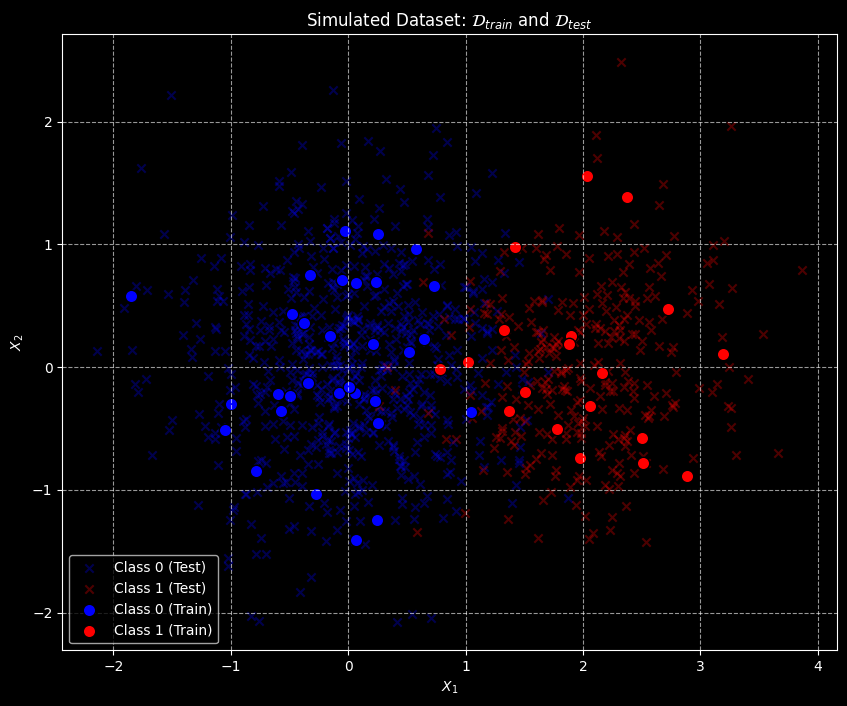

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Fixer la graine aléatoire pour pouvoir reproduire les mêmes résultats
np.random.seed(42)

def generate_data(N, epsilon, p):
    U = np.random.rand(N)
    y = (U < p).astype(int)
    X = np.zeros((N, 2))
    mu_0 = np.array([0, 0])
    Sigma_0 = np.array([[0.5, 0], [0, 0.5]])
    mu_1 = np.array([epsilon, 0])
    Sigma_1 = np.array([[0.4, 0], [0, 0.4]])

    n_0 = np.sum(y == 0)
    n_1 = np.sum(y == 1)

    X[y == 0] = np.random.multivariate_normal(mu_0, Sigma_0, n_0)
    X[y == 1] = np.random.multivariate_normal(mu_1, Sigma_1, n_1)

    return X, y

X_train, y_train = generate_data(N=50, epsilon=2, p=0.30)
X_test, y_test = generate_data(N=1000, epsilon=2, p=0.30)

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(X_test[y_test == 0, 0], X_test[y_test == 0, 1],
           c='blue', marker='x', alpha=0.3, label='Class 0 (Test)')
ax.scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1],
           c='red', marker='x', alpha=0.3, label='Class 1 (Test)')
ax.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1],
           c='blue', marker='o', s=80, edgecolor='black', label='Class 0 (Train)')
ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1],
           c='red', marker='o', s=80, edgecolor='black', label='Class 1 (Train)')
ax.set_title(r'Simulated Dataset: $\mathcal{D}_{train}$ and $\mathcal{D}_{test}$')
ax.set_xlabel(r'$X_1$')
ax.set_ylabel(r'$X_2$')
ax.legend(loc='best')
ax.grid(True, linestyle='--', alpha=0.6)

plt.show()

**(b)** What is the mathematical expression for the optimal Bayes classifier in this setting? And for its boundary region? Remember that the Bayes classifier can be written in terms of the ratio of $\text{Prob}(Y = 1 \mid \mathbf{x})$ over $\text{Prob}(Y = 0 \mid \mathbf{x})$ and that the values of $\mathbf{x} \in \mathbb{R}^2$ for which this ratio is 1 are those defining its boundary. Beware, however, that in this exercise we're considering $\text{Prob}(Y = 1) = p$ and $\text{Prob}(Y = 0) = 1-p$, so they are not necessarily always equal.

The optimal Bayes classifier assigns the label $\hat{y}(\mathbf{x}) = 1$ when the posterior probability ratio is greater than 1:

$$\frac{\text{Prob}(Y=1 \mid \mathbf{x})}{\text{Prob}(Y=0 \mid \mathbf{x})} \geq 1$$

Applying Bayes' theorem and substituting the multivariate normal probability density functions, we get:

$$\frac{p \cdot p_{\mathcal{N}(\boldsymbol{\mu}_1, \boldsymbol{\Sigma}_1)}(\mathbf{x})}{(1-p) \cdot p_{\mathcal{N}(\boldsymbol{\mu}_0, \boldsymbol{\Sigma}_0)}(\mathbf{x})} \geq 1$$

To find the boundary region, we look for the points $\mathbf{x}$ where this ratio is exactly equal to 1. It is mathematically easier to apply the natural logarithm to this equation. This gives us the log-discriminant function $\delta(\mathbf{x}) = 0$:

$$\delta(\mathbf{x}) = \log\frac{p}{1-p} - \frac{1}{2}\log\frac{\det\boldsymbol{\Sigma}_1}{\det\boldsymbol{\Sigma}_0} - \frac{1}{2}(\mathbf{x}-\boldsymbol{\mu}_1)^\top \boldsymbol{\Sigma}_1^{-1}(\mathbf{x}-\boldsymbol{\mu}_1) + \frac{1}{2}(\mathbf{x}-\boldsymbol{\mu}_0)^\top \boldsymbol{\Sigma}_0^{-1}(\mathbf{x}-\boldsymbol{\mu}_0) = 0$$

Because the covariance matrices are different ($\boldsymbol{\Sigma}_0 \neq \boldsymbol{\Sigma}_1$), the quadratic terms in $\mathbf{x}$ do not cancel out.

Using the specific values from our dataset ($\boldsymbol{\Sigma}_0 = 0.5\mathbf{I}$, $\boldsymbol{\Sigma}_1 = 0.4\mathbf{I}$, $\boldsymbol{\mu}_0 = [0, 0]^\top$, and $\boldsymbol{\mu}_1 = [\varepsilon, 0]^\top$), the equation simplifies to:

$$\delta(\mathbf{x}) = \log\frac{p}{1-p} + \log\frac{5}{4} - 0.25\|\mathbf{x}\|^2 + 2.5\varepsilon x_1 - 1.25\varepsilon^2 = 0$$

By dividing by $-0.25$ and completing the square for $x_1$, we can rewrite this boundary equation as:

$$(x_1 - 5\varepsilon)^2 + x_2^2 = 20\varepsilon^2 + 4\log\frac{p}{1-p} + 4\log\frac{5}{4}$$

This means the boundary region is a circle centered at $(5\varepsilon, 0)$ with a radius $r = \sqrt{20\varepsilon^2 + 4\log\frac{p}{1-p} + 4\log\frac{5}{4}}$.

**(c)** Implement a Bayes classifier for this setup using scikit-learn's API as explained [here](https://scikit-learn.org/stable/developers/develop.html). This means that you will be writing a new classifier that follows the same logic and API as scikit-learn, but does not exist in the package. Use your implementation to estimate the error of the Bayes classifier on the samples from $\mathcal{D}(10^4 \mid 2, 0.3)$. How would you expect your results to change for other values of $\varepsilon$? Plot a curve showing how the Bayes error rate changes for different choices $\varepsilon$ (note that you will have to generate new datasets for this).

Bayes error rate on D(10^4 | eps=2, p=0.3): 0.0624


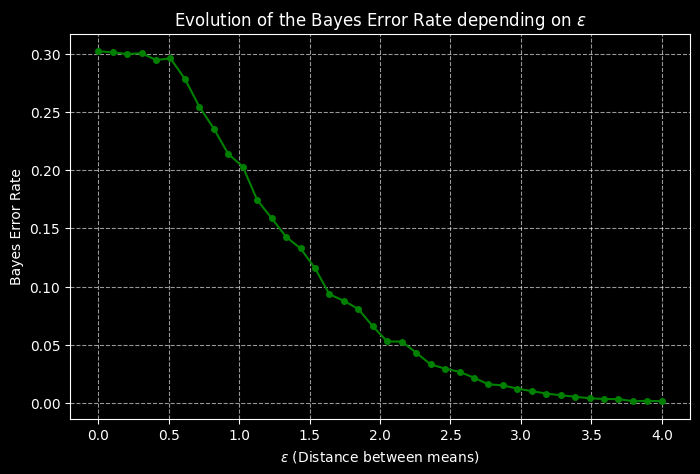

In [3]:
from sklearn.base import BaseEstimator, ClassifierMixin
from scipy.stats import multivariate_normal
import numpy as np
import matplotlib.pyplot as plt

class BayesClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, mu_0, Sigma_0, mu_1, Sigma_1, p):
        self.mu_0 = mu_0
        self.Sigma_0 = Sigma_0
        self.mu_1 = mu_1
        self.Sigma_1 = Sigma_1
        self.p = p

    def fit(self, X, y=None):
        self.classes_ = np.array([0, 1])
        return self

    def predict_proba(self, X):
        p1 = self.p * multivariate_normal.pdf(X, mean=self.mu_1, cov=self.Sigma_1)
        p0 = (1 - self.p) * multivariate_normal.pdf(X, mean=self.mu_0, cov=self.Sigma_0)

        total = p0 + p1 + 1e-15
        return np.column_stack([p0 / total, p1 / total])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

mu_0 = np.array([0.0, 0.0])
Sigma_0 = np.array([[0.5, 0.0], [0.0, 0.5]])
Sigma_1 = np.array([[0.4, 0.0], [0.0, 0.4]])
p = 0.30

mu_1_ref = np.array([2.0, 0.0])
bayes_clf = BayesClassifier(mu_0, Sigma_0, mu_1_ref, Sigma_1, p)

X_large, y_large = generate_data(N=10000, epsilon=2, p=0.30)
bayes_clf.fit(X_large, y_large) # Correct sklearn practice
bayes_error = 1 - bayes_clf.score(X_large, y_large)
print(f"Bayes error rate on D(10^4 | eps=2, p=0.3): {bayes_error:.4f}")

epsilons = np.linspace(0, 4, 40)
bayes_errors = []

for eps in epsilons:
    clf_eps = BayesClassifier(mu_0, Sigma_0, np.array([eps, 0.0]), Sigma_1, p)
    X_eps, y_eps = generate_data(N=10000, epsilon=eps, p=0.30)
    clf_eps.fit(X_eps, y_eps)
    bayes_errors.append(1 - clf_eps.score(X_eps, y_eps))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epsilons, bayes_errors, marker='o', markersize=4, color='green')
ax.set_xlabel(r'$\varepsilon$ (Distance between means)')
ax.set_ylabel('Bayes Error Rate')
ax.set_title(r'Evolution of the Bayes Error Rate depending on $\varepsilon$')
ax.grid(True, linestyle='--', alpha=0.6)
plt.show()

When we increase the value of $\varepsilon$, the distance between the mean of class 0 ($\boldsymbol{\mu}_0$) and the mean of class 1 ($\boldsymbol{\mu}_1$) becomes larger. Because the two Gaussian distributions are moving further apart, they overlap much less. Therefore, it becomes significantly easier for the classifier to separate the two classes, and we expect the Bayes error rate to decrease towards 0. The plot confirms this behavior: the error is highest when $\varepsilon = 0$ (the distributions share the same center) and approaches zero as $\varepsilon$ grows.

**(d)** Given the structure of the model generating the datasets, which classifier presented in our lectures seems to be the most adequate? Justify your answer in terms of the assumptions behind the construction of each classifier.

The most adequate classifier for this dataset is Quadratic Discriminant Analysis (QDA).

Our data is explicitly generated using normal (Gaussian) distributions for each class. QDA is built exactly on this assumption, as it estimates a specific mean and a specific covariance matrix for each individual class.

We should not use Linear Discriminant Analysis (LDA) here. LDA assumes that both classes share the exact same covariance matrix. In our simulated dataset, this assumption is violated because the covariance matrices are different ($\boldsymbol{\Sigma}_0 \neq \boldsymbol{\Sigma}_1$).

Finally, while logistic regression could work, it is a more general model that does not assume any specific distribution for the data. Since we already know that our dataset follows a Gaussian structure, QDA is much more optimized and efficient to use in this specific context.

**(e)** Using `sklearn`, train a LDA, a QDA, and a logistic regression classifier on $\mathcal{D}_\text{train}$ and estimate their errors on the samples from $\mathcal{D}_\text{test}$. How do their errors compare to the value obtained in (c)? Can we expect the gap between the Bayes error rate and test error for each classifier change when the number of samples in $\mathcal{D}_{\text{train}}$ in change? Justify your answer both theoretically and empirically.

Classifier               Test Error
------------------------------------
LDA                          0.0660
QDA                          0.0680
Logistic Regression          0.0670
Bayes                        0.0624


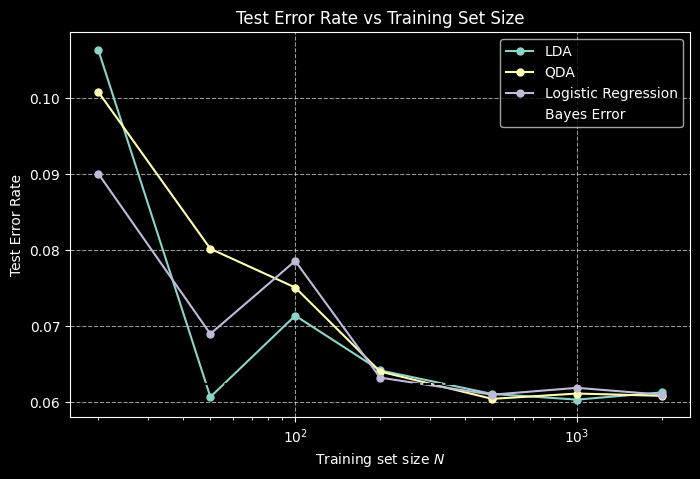

In [5]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression

classifiers = {
    'LDA': LinearDiscriminantAnalysis(),
    'QDA': QuadraticDiscriminantAnalysis(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
}

print(f"{'Classifier':<22} {'Test Error':>12}")
print("-" * 36)
for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    err = 1 - clf.score(X_test, y_test)
    print(f"{name:<22} {err:>12.4f}")
print(f"{'Bayes':<22} {bayes_error:>12.4f}")

# Empirical convergence: test error vs training set size
train_sizes = [20, 50, 100, 200, 500, 1000, 2000]
errors_by_clf = {name: [] for name in classifiers}

X_ref, y_ref = generate_data(N=20000, epsilon=2, p=0.30)

for n in train_sizes:
    X_n, y_n = generate_data(N=n, epsilon=2, p=0.30)
    for name, clf in classifiers.items():
        clf.fit(X_n, y_n)
        errors_by_clf[name].append(1 - clf.score(X_ref, y_ref))

fig, ax = plt.subplots(figsize=(8, 5))
for name, errs in errors_by_clf.items():
    ax.plot(train_sizes, errs, marker='o', markersize=5, label=name)
ax.axhline(bayes_error, color='black', linestyle='--', linewidth=1.5, label='Bayes Error')
ax.set_xlabel('Training set size $N$')
ax.set_ylabel('Test Error Rate')
ax.set_title('Test Error Rate vs Training Set Size')
ax.set_xscale('log')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)
plt.show()

The test errors of the three classifiers are slightly higher than the Bayes error, but they are all very close to it. This happens because $\varepsilon = 2$ makes the two classes relatively easy to separate. Among the three models, QDA usually gets the closest score to the optimal Bayes classifier because its mathematical assumptions perfectly match how our data was generated.

If we increase the number of samples in the training set $\mathcal{D}_{\text{train}}$, the gap between the test error and the Bayes error shrinks. Theoretically, this happens because having more data allows the models to estimate their internal parameters (like the means and covariance matrices for QDA) much more accurately. As the estimations get closer to the true parameters, the model's performance gets closer to the theoretical limit.

Empirically, the plot confirms this behavior. We can clearly see that when the training size is small, the error rates are higher and can be unstable. As the training size grows, the curves drop and slowly converge towards the black dashed line, which represents the optimal Bayes error rate.

However, on the small training set of $50$ samples, QDA actually performs slightly worse than LDA. This perfectly illustrates the bias-variance tradeoff: because class 1 only has about $15$ samples, QDA struggles to accurately estimate a separate covariance matrix (high variance), whereas LDA benefits from estimating a single pooled covariance matrix using all $50$ points, making it more robust despite its incorrect theoretical assumption. As shown on the plot, QDA overtakes LDA and becomes the best model when the sample size $N$ gets large enough.

**(f)** Consider a new test set defined as $\mathcal{D}'_\text{test} = \mathcal{D}(1000 \mid 0.5, 0.7)$. Use the same classifiers trained in (e) and estimate their new test errors. Do you observe any difference in the results? Can you explain what is happening?

In [6]:
X_test2, y_test2 = generate_data(N=1000, epsilon=0.5, p=0.7)

print(f"{'Classifier':<22} {'Error D_test':>14} {'Error D_test_prime':>20}")
print("-" * 58)
for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    e1 = 1 - clf.score(X_test, y_test)
    e2 = 1 - clf.score(X_test2, y_test2)
    print(f"{name:<22} {e1:>14.4f} {e2:>20.4f}")

bayes_clf2 = BayesClassifier(mu_0, Sigma_0, np.array([0.5, 0.0]), Sigma_1, p=0.7)
bayes_clf2.fit(X_test2, y_test2)
bayes_error2 = 1 - bayes_clf2.score(X_test2, y_test2)

print(f"{'Bayes (optimal)':<22} {'---':>14} {bayes_error2:>20.4f}")

Classifier               Error D_test   Error D_test_prime
----------------------------------------------------------
LDA                            0.0660               0.5870
QDA                            0.0680               0.5840
Logistic Regression            0.0670               0.5910
Bayes (optimal)                   ---               0.2770


We observe a massive increase in the error rates. The trained classifiers go from an error of about $6\%$ on the original test set to almost $59\%$ on the new one.

Part of this increase is expected. Because the distance between the classes is now much smaller ($\varepsilon = 0.5$ instead of $2$), the two Gaussian distributions overlap heavily. Even a perfectly adapted Bayes classifier makes about $28\%$ of errors on this new data.

However, our trained models perform significantly worse than $28\%$. This happens because the rules they learned during training no longer apply to this new dataset. This problem is known as distribution shift, and it occurs here for two main reasons.

First, the class proportions are completely different. During training, the models learned that class 1 is a minority ($p=0.3$), so they have a natural bias to predict class 0. In the new test set, class 1 is actually the large majority ($p=0.7$). Because of their learned bias, the models will systematically misclassify a lot of class 1 points.

Second, the geographical position of the data changed. The models originally drew a boundary line to separate two populations located at $x=0$ and $x=2$. Now that the second population is located at $x=0.5$, the old boundary line is completely misplaced, leaving a huge amount of data points on the wrong side of the decision region.

## ▶️ Part 2: Real data

In this part we will consider the Titanic dataset available [here](https://www.kaggle.com/competitions/titanic/data). The goal here will be to build a machine learning model that predicts which passengers survived the Titanic shipwreck. Each passenger (i.e., data point) is composed of a set of categorical and continuous features, and its labels are either 0 (dead) or 1 (survived).

First of all, you should download both the `training` and the `test` datasets.

-- The `training` set should be used to build your machine learning models. The labels for each passenger are provided. Your model will be based on “features” like passengers’ gender and class. You can also use feature engineering to create new features.

-- The `test` set should be used to see how well your model performs on unseen data. For the test set, we do not provide the ground truth for each passenger. It is your job to predict these outcomes. For each passenger in the test set, use the model you trained to predict whether or not they survived the sinking of the Titanic.

Follow the guidelines from [here](https://www.kaggle.com/competitions/titanic/overview) to understand how to submit the results of your predictions on the `test` set and obtain the score of your model.

### Suggestions:

-- Don't hesitate to do some exploratory data analysis before building your machine learning model. You chould check, for instance, which kind of cross-validator seems the most appropriate for assessing the score of your classifier : are the data points completely IID? are they ordered somehow? split into groups? Beware of all this.

-- Since you will be handling predictors with different data types, it might be useful to take a look at the concept of `ColumnTransformer` from scikit-learn [here](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html). You could also check these two videos about how to build complext pipelines [1](https://www.youtube.com/watch?v=7TZ7j4HSzmE) and [2](https://www.youtube.com/watch?v=lhMqqauXtW0).

-- Take a look at the package [`skrub`](https://skrub-data.org/stable/). You would be surprised with how easy it is to get a very good score on this dataset using `tabular_learner`.

**(a)** Explain the feature engineering that you had to do with the dataset. If you've used `skrub`, explain how the encoding for each kind of predictor was decided.

We decided to use the skrub package to simplify the feature engineering and preprocessing steps. First, we dropped columns that were purely identifiers or contained too many unique string values, such as PassengerId, Name, Ticket, and Cabin.

Instead of manually building a complex transformer to handle missing values and categorical variables, we used the tabular pipeline function from skrub. This function automatically analyzes the data types of the input columns and builds an optimized pipeline. Numerical predictors are passed directly to the classifier, which natively handles missing values. Categorical predictors are automatically detected and encoded depending on their cardinality.

This automated approach prevents data leakage and provides a robust baseline without the need for manual preprocessing.

In [8]:
import pandas as pd
from skrub import tabular_pipeline
from sklearn.model_selection import cross_val_score

train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

y_train = train_df["Survived"]
X_train = train_df.drop(columns=["Survived", "PassengerId", "Name", "Ticket", "Cabin"])
X_test = test_df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

model = tabular_pipeline("classification")

cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
print(f"5-fold CV accuracy : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

model.fit(X_train, y_train)
predictions = model.predict(X_test)

submission = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived": predictions
})
submission.to_csv("my_submission.csv", index=False)
print("Fichier my_submission.csv créé avec succès !")

5-fold CV accuracy : 0.8283 ± 0.0305
Fichier my_submission.csv créé avec succès !


**(b)** What type of classifier did you end up using? Why? What was your score in the public leaderboard from Kaggle?

We ended up using a Histogram-based Gradient Boosting Classifier, which is the default model automatically selected by the skrub tabular pipeline.

We chose this classifier because tree-based methods are excellent at handling datasets with mixed feature types, such as continuous variables like Age and categorical variables like Sex. It also naturally captures complex, non-linear interactions between features, for instance, the combined survival effect of being a female in first class, without needing manual adjustments. Furthermore, this specific algorithm is highly robust, fast, and handles missing values natively.

Finally, after submitting our predictions, we achieved a score of 0.76315 on the public Kaggle leaderboard.